# Titulo: Introducción a la modelos espaciales.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [46]:
# Modulos completos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# Algunas clases especificas de modulos

from google.colab import drive
from libpysal.weights import Queen
from pysal.viz import splot
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import plot_moran
from splot import esda as esdaplot
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    acorr_breusch_godfrey,
    het_white
)
from statsmodels.stats.stattools import durbin_watson, jarque_bera



## Mapa temático para identificar el fenómeno

In [47]:
# Configuración de google drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/México_ent_22/00ent'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pobreza_Mexico_2016_2022_ent.xlsx'

In [49]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [50]:
# Cargar datos aportación de René

Data = pd.read_excel(ruta_data, dtype = {'CVE_ENT':str})

Data.head(1)

,CVE_ENT,NOM_ENT,Año,Pobreza_per,PIB,Población,Ocupacion,Desocupacion,Ocupacion_rel,Desocupacion_rel,PIB_percapita
0,01,Aguascalientes,2016,28.9,307395.841,1367412,549236,22199,0.961152,0.038848,224801.187206


In [51]:
# Verificar columnas

Mapa[['CVE_ENT', 'NOMGEO']].dtypes

,0
CVE_ENT,object
NOMGEO,object


In [52]:
Data[['CVE_ENT', 'NOM_ENT']].dtypes

,0
CVE_ENT,object
NOM_ENT,object


In [53]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Data[Data['Año'] == 2022],
    left_on= ["CVE_ENT","NOMGEO"],
    right_on=["CVE_ENT","NOM_ENT"],
    how = 'left'
)

In [54]:
Mapa

Output hidden; open in https://colab.research.google.com to view.

In [55]:
Mapa.dtypes

,0
CVEGEO,object
CVE_ENT,object
NOMGEO,object
geometry,geometry
NOM_ENT,object
Año,int64
Pobreza_per,float64
PIB,float64
Población,int64
Ocupacion,int64


In [56]:
# Transformación de variables porcentuales

Mapa['Desocupacion_rel'] = Mapa['Desocupacion_rel']*100

In [57]:
# Modelo OLS

## Construcción de vectores y matrices

Y = Mapa['Pobreza_per']

X = pd.DataFrame({
    'Intercepto': 1,
    'DES_rel': Mapa['Desocupacion_rel'],
    'PIB_per': Mapa['PIB_percapita']
})

## Estimación del modelo

mod_ols = sm.OLS(Y,X).fit()

In [58]:
# Revisar tabla ANOVA para el anális inicial del modelo

print(mod_ols.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:            Pobreza_per   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.753
Date:                Fri, 16 Jan 2026   Prob (F-statistic):              0.191
Time:                        04:00:51   Log-Likelihood:                -129.59
No. Observations:                  32   AIC:                             265.2
Df Residuals:                      29   BIC:                             269.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercepto    49.4810      9.142      5.412      0.0

In [59]:
# Verificar con Breusch-Pagan de heterocedasticidad

bp_test = het_breuschpagan(mod_ols.resid, X)
print("\nBreusch-Pagan")
print(f"LM Stat: {bp_test[0]}")
print(f"p-valor: {bp_test[1]}")


Breusch-Pagan
LM Stat: 1.1629840212106188
p-valor: 0.5590636151484274


In [73]:
# Prueba de White con productos cruzados

# 1. Sacar residuales

residuos = mod_ols.resid


# 2. Matriz de regresores para la prueba de White
#    Incluye: constante, variables originales, cuadrados y producto cruzado
X_white = pd.DataFrame({
    'const': 1,
    'Desocupacion_rel': Mapa['Desocupacion_rel'],
    'PIB_Per': Mapa['PIB_percapita']
})

# 3. Prueba de White
white_test = het_white(residuos, X_white)

# 4. Resultados
labels = [
    'Estadístico LM',
    'p-valor LM',
    'Estadístico F',
    'p-valor F'
]

resultados = dict(zip(labels, white_test))

# 5. Mostrar resultados
for k, v in resultados.items():
    print(f"{k}: {v}")

Estadístico LM: 2.569442327506362
p-valor LM: 0.766002521767152
Estadístico F: 0.45398732337038306
p-valor F: 0.8065202504935052


In [61]:
# Obtener un dataframe para los residuales enlazados a la entidad

Residuales_ols = pd.DataFrame({
    'CVE_ENT': Mapa['CVE_ENT'],
    'Residuos': mod_ols.resid
})

Residuales_ols

,CVE_ENT,Residuos
0,01,-5.338229
1,02,-21.348445
2,03,-20.671869
3,04,6.671170
4,05,-12.782624
5,06,-16.268437
6,07,30.468311
7,08,-20.945941
8,09,2.968510
9,10,1.556377


In [62]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Residuales_ols,
    left_on= ["CVE_ENT"],
    right_on=["CVE_ENT"],
    how = 'left'
)

<Figure size 7500x6000 with 0 Axes>

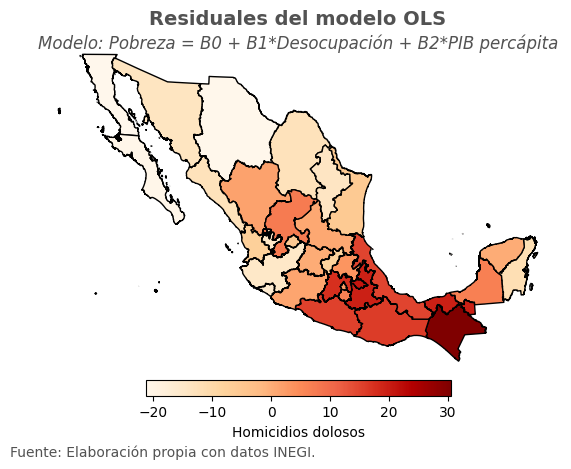

In [68]:
# Definición de paleta

# Mapa temático con variable continua

plt.figure(figsize=(15,12), dpi = 500)
Mapa.plot(
    column = 'Residuos',
    legend = True,
    cmap = 'OrRd',
    legend_kwds = {'label': "Homicidios dolosos",
                   'orientation': 'horizontal',
                   'shrink': 0.5, # Reduce el tamaño a la mitad
                   'pad': 0.01},
    edgecolor = "black"
)
plt.axis('off') # Quita los ejes
plt.figtext(0.5, 0.95, "Residuales del modelo OLS",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.5, 0.90, "Modelo: Pobreza = B0 + B1*Desocupación + B2*PIB percápita",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,1,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Mapa_residuos_ols.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

## Matrices de pesos espaciales


1. Contiguedad de Reina



In [74]:
# Cálculo de matriz

W_queen = Queen.from_dataframe(Mapa, ids = "CVE_ENT")

# Normalizar filas

W_queen.transform = 'r'

## Estadístico de Moran Global

1. Mediante matriz de peso espacial de reina

In [75]:
# Estadístico

Moran_WQ = esda.moran.Moran(Mapa['Residuos'], W_queen)

In [76]:
print(f"El valor del índice es de: {Moran_WQ.I:.2f}")
print(f"El valor estadístico Z de Moran es de: {Moran_WQ.z_norm:.2f}")
print(f"El valor de probabilidad del estadístico Z de Moran es de: {Moran_WQ.p_norm:.2f}")

El valor del índice es de: 0.65
El valor estadístico Z de Moran es de: 5.47
El valor de probabilidad del estadístico Z de Moran es de: 0.00


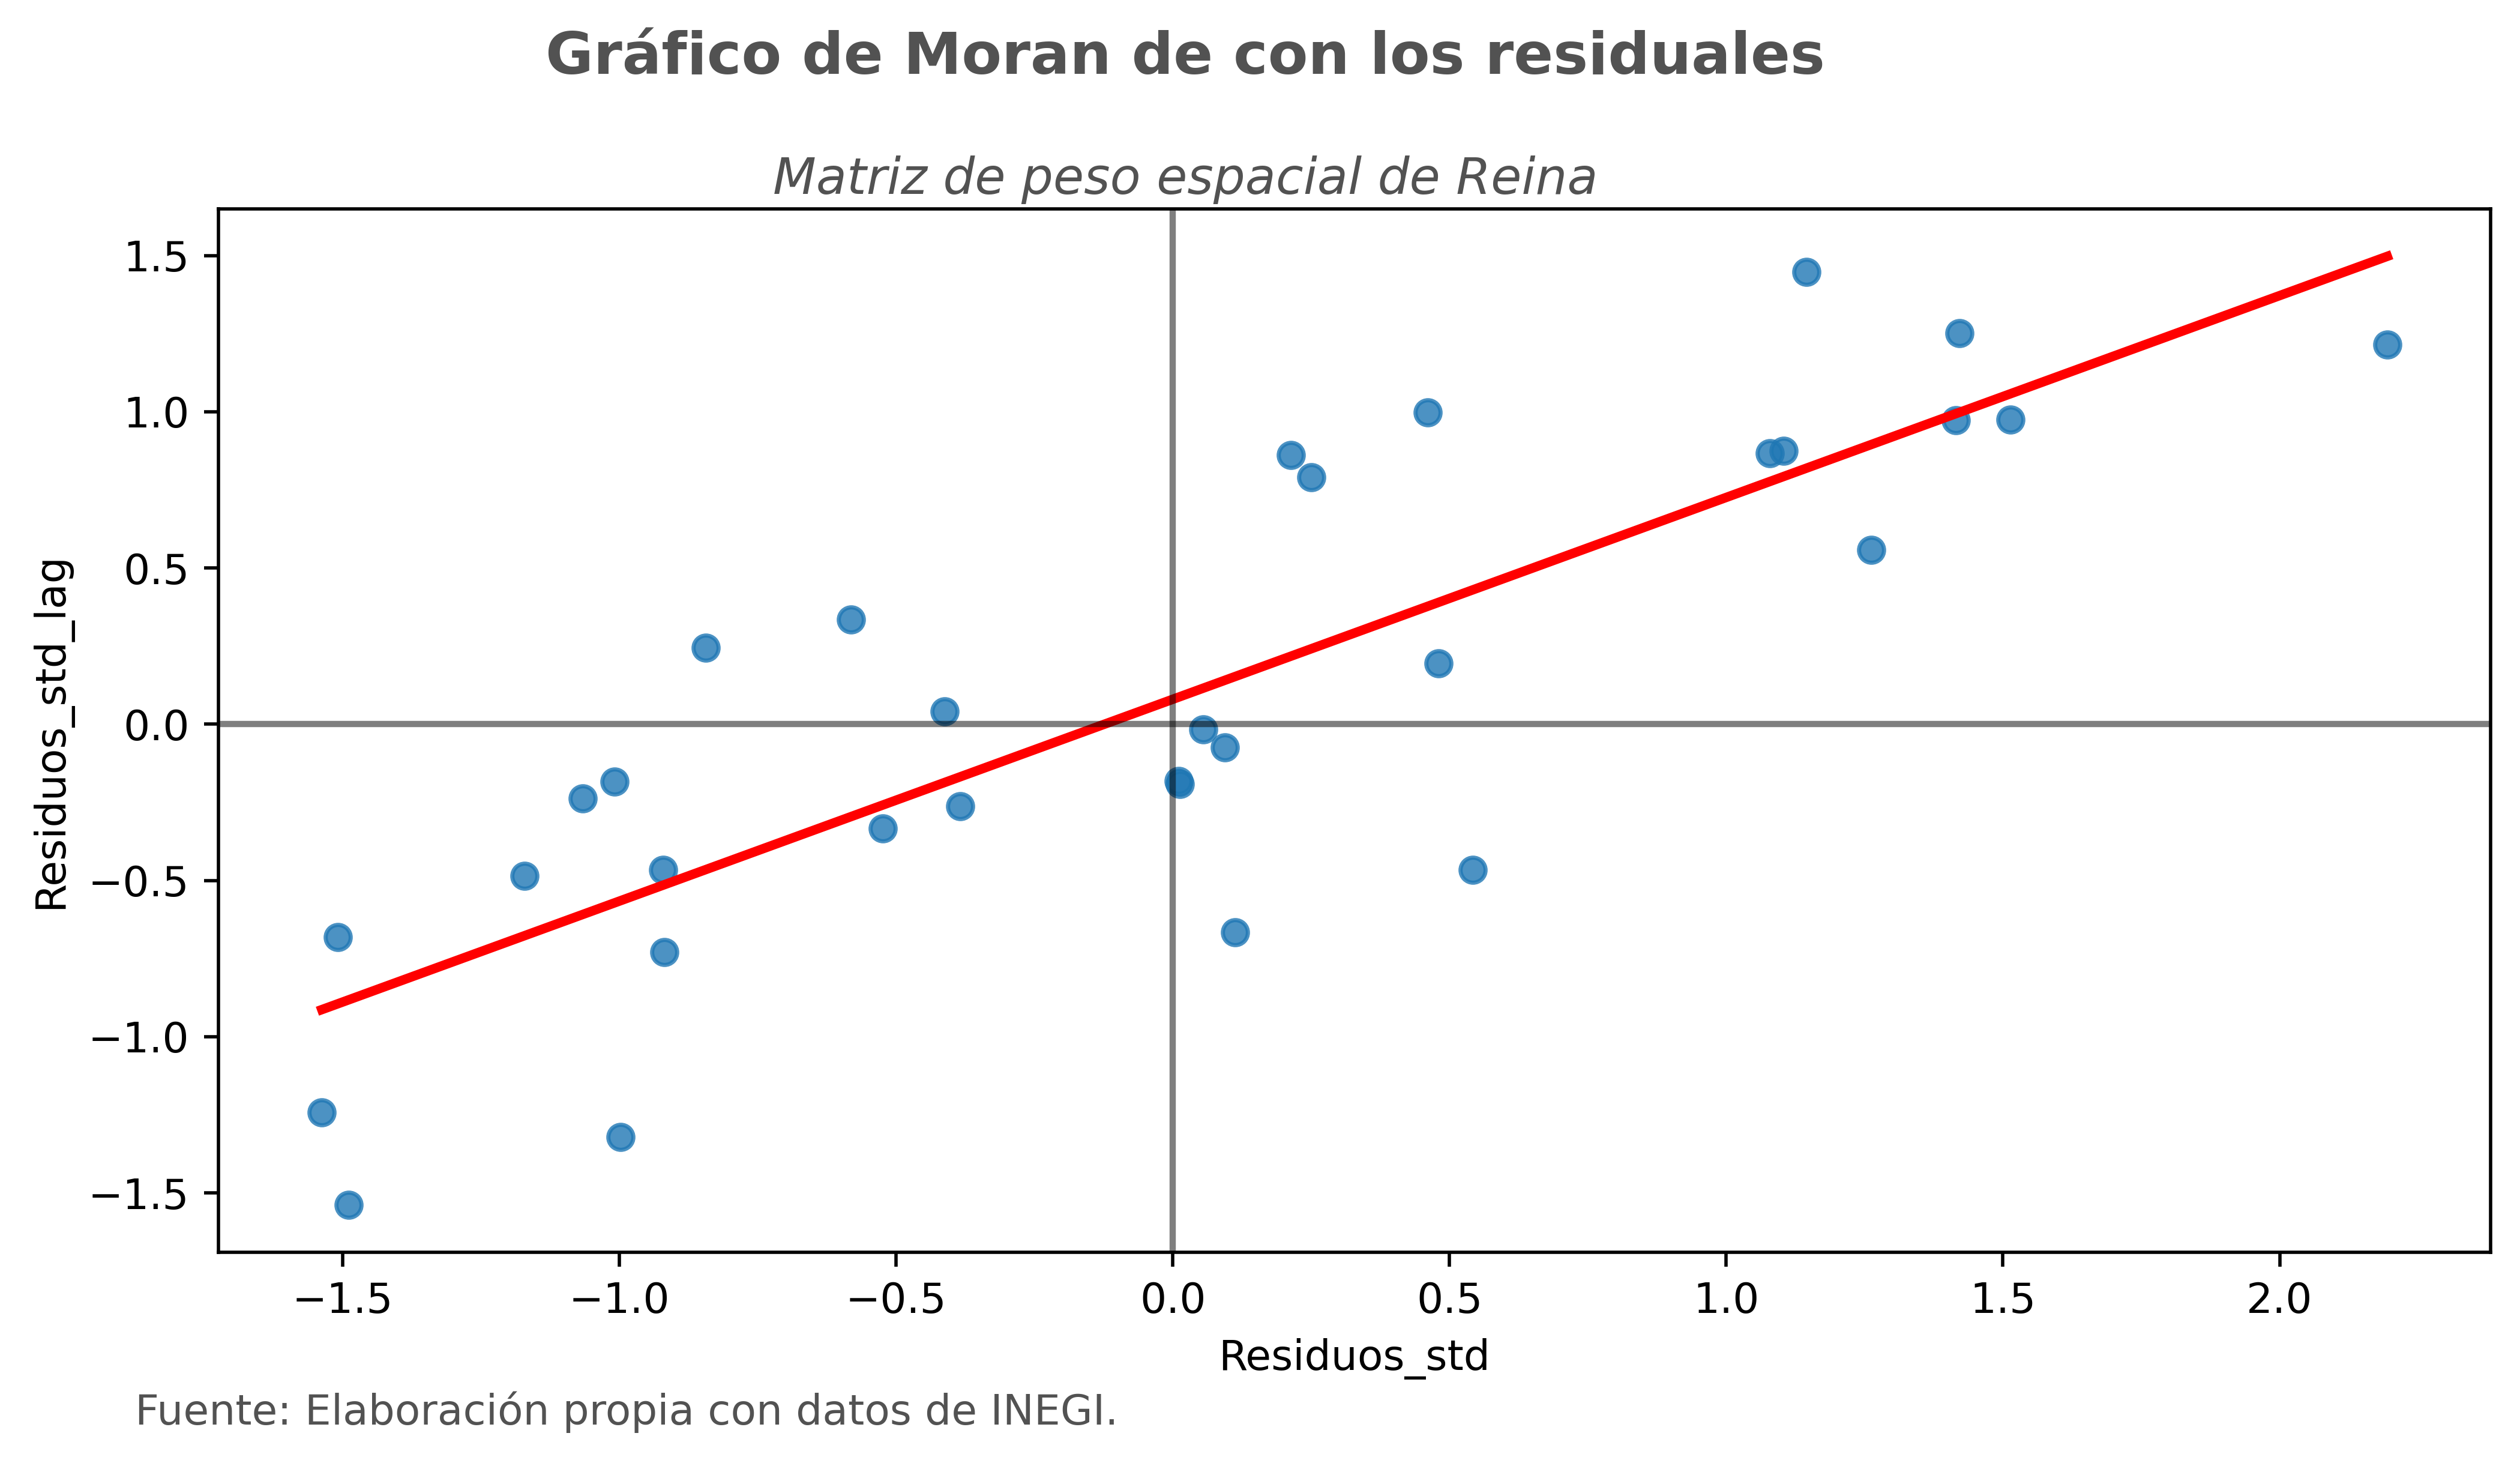

In [79]:
# Gráfico

Mapa['Residuos_std'] = (Mapa['Residuos']-Mapa['Residuos'].mean())/np.std(Mapa['Residuos'])
Mapa['Residuos_std_lag'] = weights.spatial_lag.lag_spatial(W_queen, Mapa['Residuos_std'])

f, ax = plt.subplots(1, figsize = (10,5), dpi = 500)
sns.regplot(
    x = 'Residuos_std',
    y = 'Residuos_std_lag',
    ci = None,
    data = Mapa,
    line_kws = {'color': 'r'}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
plt.figtext(0.4, 0.95, "Gráfico de Moran de con los residuales",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de peso espacial de Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Moran_Reina_residual_ols.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

